# SVM MNIST Experiments

This notebook wires up the utilities in `MNIST_models/svm_MNIST` to reproduce three tiers of experiments:

1. Baseline linear SVM in pixel space
2. Random projection variants of the linear SVM
3. Kernel SVMs inspected through their dual variables

Each block is parameterized so you can expand runs (more seeds/epochs) without changing the code structure.


In [6]:
import sys,os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
print(sys.path[-1])
from MNIST_models.svm_MNIST.data_utils import load_and_project
from MNIST_models.svm_MNIST.linear_svm import LinearSVMConfig, run_multiple_seeds
from MNIST_models.svm_MNIST.kernel_svm import KernelConfig, multi_seed_kernel
from MNIST_models.svm_MNIST.workflow import (
    run_kernel_sweep,
    run_linear_sweep,
    run_projection_grid,
 )
import MNIST_models.graph_print_analysis as gpa
import Hilbert_computation as hc

c:\Users\ASUS\Desktop\cone_dynamics


## 1. Baseline linear SVM (pixel space)

Use a compact training loop that logs the parameter trajectory. Increase `num_epochs`, `record_interval`, or `seeds` when you want finer Hilbert distance curves or more endpoints for the spectral study.


In [ ]:
# Load the fixed 3-vs-8 split without projection
baseline_split = load_and_project(max_samples=5000, random_state=0, target_dim=None)

lr=1e-3
weight_decay=1e-4
batch_size=16
num_epochs=100
log_interval=1
# Lightweight config to keep the example quick; bump epochs for full study
linear_cfg = LinearSVMConfig(lr=lr, weight_decay=weight_decay, batch_size=batch_size, num_epochs=num_epochs, log_interval=log_interval)

# HILBE



baseline_runs = run_multiple_seeds(
    baseline_split.X_train,
    baseline_split.y_train,
    config=linear_cfg,
    seeds=[0, 1],
 )

# Inspect Hilbert/angle/distance metrics for the first run

# ============================
# Compute trajectory metrics
# ============================


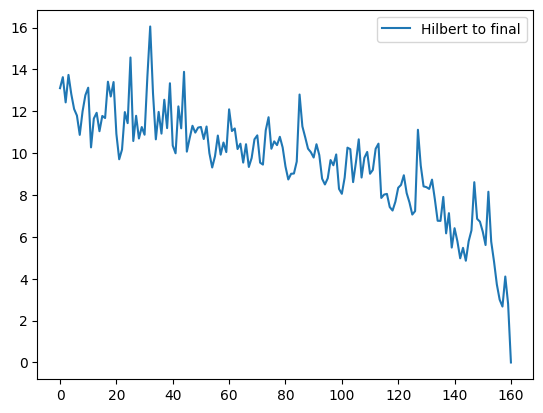

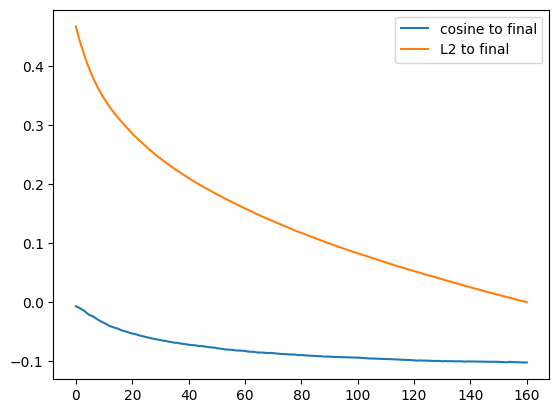

In [25]:
first_run = baseline_runs[0]
Trajectory_some=first_run.metrics
# dict_keys(['hilbert_to_final', 'hilbert_between', 'hilbert_to_init', 'l2_to_final', 'cosine_to_final'])
trajectory=Trajectory_some.trajectory
final_w=trajectory[-1]
initial_w=trajectory[0]
result=gpa.analysis_to_w_star(trajectory,final_w,if_plot=True,if_save=False,if_show=False,if_writes=True,if_masked=False)
hilbert_to_final=result['hilbert_to_w_star']
plt.figure()
plt.plot(hilbert_to_final,label='Hilbert to final')
plt.legend()
plt.show()

cosin=Trajectory_some.cosine_to_final
l2=Trajectory_some.l2_to_final
import matplotlib.pyplot as plt
plt.figure()
plt.plot(cosin,label='cosine to final')
plt.plot(l2,label='L2 to final')
plt.legend()
plt.show()

## 2. Random projection variants

Sweep over several embedding dimensions to see how the final-direction spectrum flattens. The helper returns both the individual runs and the singular values of stacked endpoints.


In [11]:
projection_dims = [None, 256, 2000]
projection_results = run_projection_grid(
    dims=projection_dims,
    seeds=[0, 1, 2],
    base_config=linear_cfg,
    data_kwargs=dict(max_samples=4000, random_state=0),
)

for dim, result in projection_results.items():
    print(f"dim={dim}: singular values -> {result.singular_values[:5]}")


dim=None: singular values -> [0.90220773 0.54801938 0.54174802]
dim=256: singular values -> [0.92787755 0.52821883 0.50961415]
dim=2000: singular values -> [0.75201639 0.57103572 0.55107022]


## 3. Kernel SVM dual-space check

Train RBF SVMs on different shuffles and analyze the dual coefficients as positive vectors inside the cone.


In [12]:
kernel_cfg = KernelConfig(C=5.0, kernel="rbf", gamma="scale")
kernel_result = run_kernel_sweep(
    split=baseline_split,
    seeds=[0, 1, 2],
    config=kernel_cfg,
)

print("Dual-alpha spectrum (top 5):", kernel_result.singular_values[:5])


Dual-alpha spectrum (top 5): [48.15989305 41.41113385 40.90641983]
